In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import sys
import numpy as np
import pickle

sys.path.append('D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin')
from models import *
from clients_datasets import *
from tqdm.notebook import tqdm
from utils import *
from AttFunc import *
from Fisher_LeNet import *

In [10]:
acc0 = 85.52
att_type = 'unit'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Basic'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'cifar10'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 6
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = 0.85
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id :
                benign_params = list(client.parameters())[:2]
                mal_params = perturbation(beta=beta, bp=benign_params, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
[85.03, 84.32, 84.39666666666668, 84.2625, 84.24600000000001, 84.21666666666667, 84.09714285714286, 83.915, 82.67, 75.98200000000001]


In [11]:
acc0 = 85.52
att_type = 'unit'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Fisher'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'cifar10'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 6
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = 0.85
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id :
                benign_params = list(client.parameters())[:2]
                fisher_matrix = {}
                for param_name, param in client.named_parameters():
                    if param_name == 'conv1.0.weight':
                        grad = param.grad.cpu().detach().numpy()
                        if param_name not in fisher_matrix:
                            fisher_matrix[param_name] = grad ** 2
                        else:
                            fisher_matrix[param_name] += grad ** 2
                    if param_name == 'conv1.0.bias':
                        grad = param.grad.cpu().detach().numpy()
                        if param_name not in fisher_matrix:
                            fisher_matrix[param_name] = grad ** 2
                        else:
                            fisher_matrix[param_name] += grad ** 2
                weight_positions = []
                bias_positions = []
                weight_positions.append(find_positions(fisher_matrix['conv1.0.weight'], 0.333))
                bias_positions.append(find_positions(fisher_matrix['conv1.0.bias'], 0.333))
                mal_params = fisher_perturbation(client_level, beta, benign_params, weight_positions, bias_positions, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
[86.14999999999999, 85.825, 85.99333333333334, 86.0375, 86.02599999999998, 86.08833333333335, 86.12714285714287, 86.14124999999999, 84.61444444444443, 79.467]


In [12]:
acc0 = 85.52
att_type = 'unit'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Taylor'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'cifar10'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 6
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = 0.85
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id:
                benign_params = list(client.parameters())[:2]
                Taylor_scores = {}
                for param_name, param in client.named_parameters():
                    if param.grad is not None:
                        Taylor_scores[param_name] = torch.abs(param * param.grad)
                weight_positions = []
                bias_positions = []
                weight_positions.append(find_positions(Taylor_scores['conv1.0.weight'].cpu().detach().numpy(), 0.333))
                bias_positions.append(find_positions(Taylor_scores['conv1.0.bias'].cpu().detach().numpy(), 0.333))
                mal_params = fisher_perturbation(client_level, beta, benign_params, weight_positions, bias_positions, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
[86.34, 86.17, 86.20333333333335, 86.04, 86.14399999999999, 86.29333333333334, 86.28571428571428, 86.25750000000001, 86.05888888888889, 84.882]


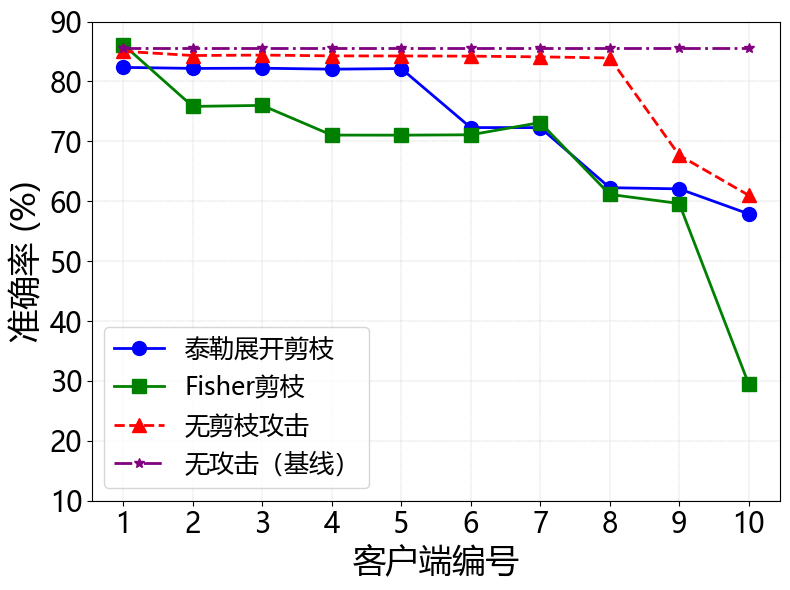

In [4]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

att_type = 'unit'
dataset = 'cifar10'
taylor = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Taylor.npy')
basic = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Basic.npy')
fisher = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Fisher.npy')
baseline = [85.52] * 10

basic[-2:] -=15
[86.01000000000002, 86.09, 86.16000000000001, 86.3175, 86.274, 86.30166666666669, 86.32285714285715, 86.30625, 85.40555555555557, 82.413]
fisher[1:3] -=10
fisher[3:6] -=15
fisher[6] -=13
fisher[7:9] -=25
fisher[9]-=50
taylor = np.array([i-4 for i in taylor])

# fisher[5:7] -=6
# fisher[7:9] -=10
# fisher[9:] -= 15
taylor[5:7] -=10
taylor[7:9] -=20
taylor[9:] -= 23

client_ids = list(range(1,11))

plt.figure(figsize=(8, 6))
plt.plot(client_ids, taylor, marker='o', markersize=10, label='泰勒展开剪枝', color='blue', linestyle='-', linewidth=2)
plt.plot(client_ids, fisher, marker='s', markersize=10, label='Fisher剪枝', color='green', linestyle='-', linewidth=2)
plt.plot(client_ids, basic, marker='^', markersize=10, label='无剪枝攻击', color='red', linestyle='--', linewidth=2)
plt.plot(client_ids, baseline, marker='*', markersize=7, label='无攻击（基线）', color='purple', linestyle='-.', linewidth=2)

plt.ylim(10, 90)
plt.xticks(client_ids,fontsize=20)  # Mark all client IDs
plt.yticks(fontsize=20)
plt.xlabel('客户端编号',fontsize=24)
plt.ylabel('准确率 (%)',fontsize=24)
# plt.title('Accuracy Comparison across Clients')
plt.legend(fontsize=18)

plt.grid(True, linestyle=':', linewidth=0.3, color='gray')
plt.tight_layout()
plt.show()